# Debugging Notebook for functions

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from encoding import *
from processing import *
from decoding import *
from visualize import *
from mesh import *
from main import *
import numpy as np
import matplotlib.pyplot as plt

# Loading data from mnist set
Functions in encoding.py

7
Number of '7' in this set: 46, number of '1' in this set: 64


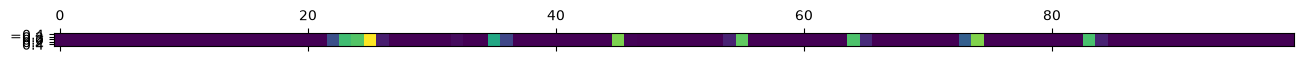

In [3]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = 110 #Sets number of samples you want to get in total
m = 10 #side length (pixel) of mnist image after downsampling
theta = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = False #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X, Y = get_data(values, mode, number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels
#Example of the first entry
plt.matshow(np.real(E_X[:,0]).reshape(1, -1)) #reshaping it just for plotting with plt.matshow
print(Y[0])

print("Number of '7' in this set: " + str(np.sum(Y == 7))+", number of '1' in this set: " + str(np.sum(Y == 1)))


# Initializing MZI-Mesh
Functions in mesh.py
(No parameter initialization yet)

Number of layers in the setup: 4
MZIs along the layers in the setup: [2, 1, 2, 1]
Total number of (trainable) MZIs in the setup: 6


<Axes: title={'center': 'N=4, 4 Layer, 6 MZIs'}, xlabel='Layer', ylabel='Channel'>

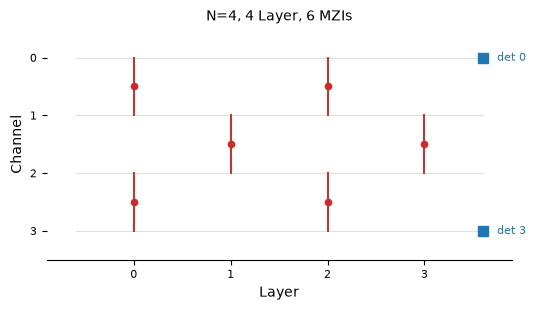

In [4]:
N=4 #Number of channels
L=4 #Number of layers
test_plan = plan_rectangular(N, L) #other plans are plan_redundant and plan_triangular
test_mesh = MZIMesh(N, test_plan) #Object containing the geometry of the MZI-Mesh

#Each mesh object carries its properties:
n_layers = test_mesh.n_layers
n_slots = test_mesh.slot_counts
n_mzis = test_mesh.n_mzis
print(f"Number of layers in the setup: {n_layers}") #layers of setup
print(f"MZIs along the layers in the setup: {n_slots}") #distribution of MZIs along the layers
print(f"Total number of (trainable) MZIs in the setup: {n_mzis}") #number of (trainable MZIs in this setup)


plot_mesh(test_mesh, color_by=None, detectors=[0, 3], label_step=None) #function of visualize.py to show the geometry (and detectors)


# Initializing Mesh parameters
Functions in mesh.py, here just init_random, also init_haar already coded (later used)

Phis: [array([2.80410142, 1.3555826 ]), array([0.92409088]), array([2.64731081, 1.78245139]), array([2.84760047])]
Thetas: [array([2.535678, 2.043243]), array([0.06692252]), array([6.26393165, 1.72485524]), array([0.06391098])]


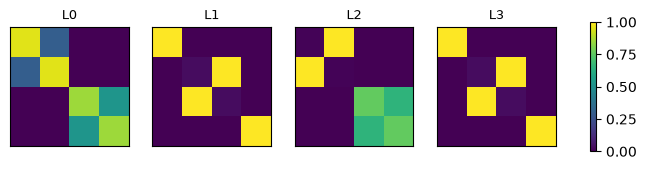

In [5]:
phis, thetas = test_mesh.init_random()
print(f"Phis: {phis}")
print(f"Thetas: {thetas}")

layers = test_mesh.layer_matrices(thetas, phis)   #building layers (transfer matrices) out of the parameters
fig, _ = plot_layers(layers, mode="Abs")


# Propagation

[[-0.03183752-1.73918760e-02j -0.02788784+3.64590511e-02j
   0.0122099 +7.17278148e-02j ... -0.00957191+1.04658159e-02j
  -0.02621423-7.12961844e-03j -0.01393973+6.20433113e-03j]
 [-0.07148157+5.93038436e-02j -0.05043318+9.88788346e-02j
  -0.00378794+7.21973359e-02j ... -0.02828353+4.19536695e-02j
  -0.06584063+7.49471920e-02j -0.04238666+6.85084475e-02j]
 [-0.00958123+5.44547111e-02j -0.03397352+6.58629484e-02j
  -0.0352782 +3.70885719e-02j ... -0.04505933+4.61293900e-02j
  -0.02135476+6.49924647e-02j -0.03933648+6.35094936e-02j]
 ...
 [ 0.02816127+2.04488481e-02j -0.00218008+1.70826444e-02j
   0.00862031+1.09101048e-02j ...  0.10647799+9.60062501e-02j
   0.11373112+1.02054283e-01j  0.09880917+7.60562967e-02j]
 [ 0.02876535+5.87964965e-02j  0.01080098+1.75044962e-02j
   0.00828722-5.24086376e-05j ...  0.07498729+8.56152784e-02j
   0.08315651+1.05376907e-01j  0.07738183+7.05957467e-02j]
 [ 0.02114845-1.60619125e-02j  0.02347184+2.38755223e-02j
   0.0425237 -9.55638034e-03j ...  0.01585

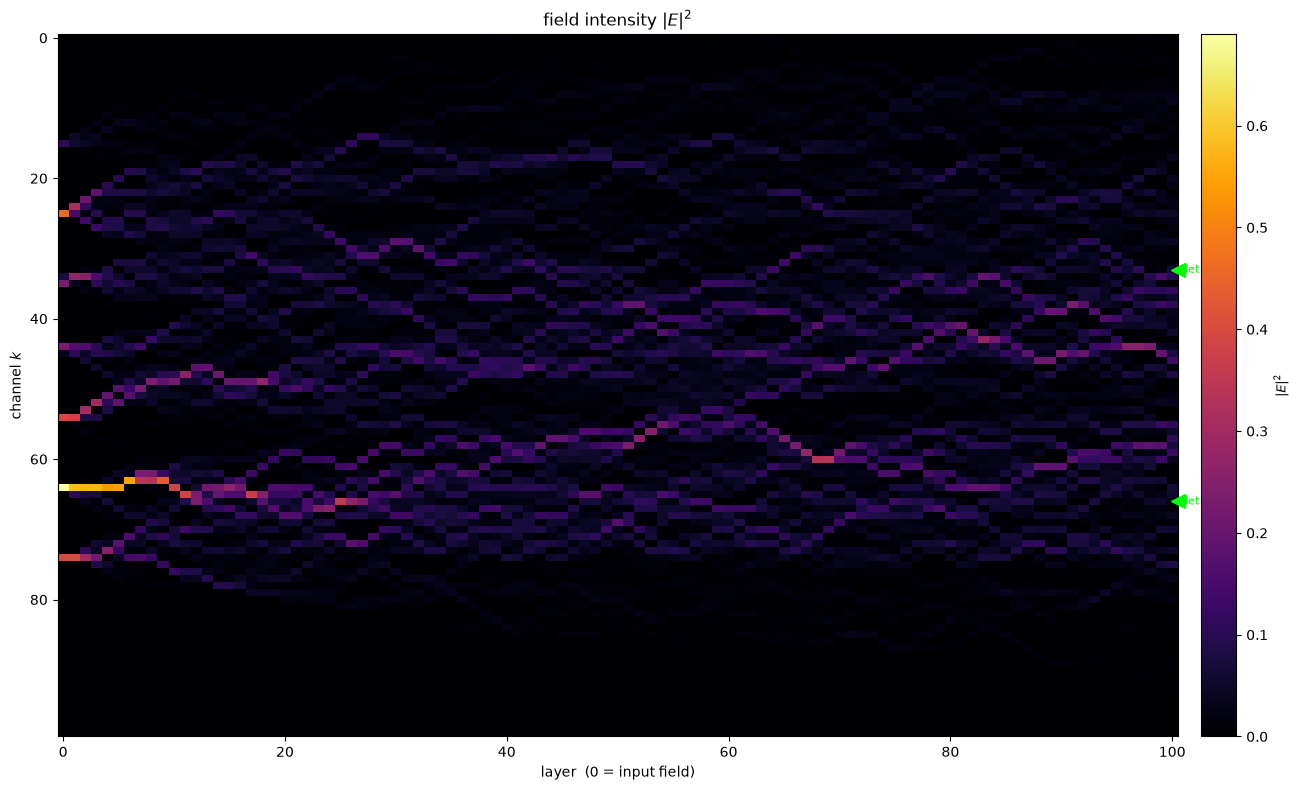

In [6]:
N=100 #number of channels (number of pixels in mnist image)
prop_mesh = MZIMesh(N, plan_rectangular(N, N)) #creating mesh object
thetas, phis = prop_mesh.init_random() #initializing random weights

layers = prop_mesh.layer_matrices(thetas, phis)   #build transfer matrices (layers) from parameters

E_out  = forward(E_X, layers)         #propagation that gives end result directly
print(E_out)                          #format: [channels, batches]
print(np.shape(E_out))

E_hist = forward_history(E_X, layers) #propagation that gives all E-fields for every layer
print(E_hist)                         #format: [layers, channels, batches]
I = np.abs(E_hist[:,:,2])**2
fig, _ = plot_intensity_map(I, detectors=[33,66])

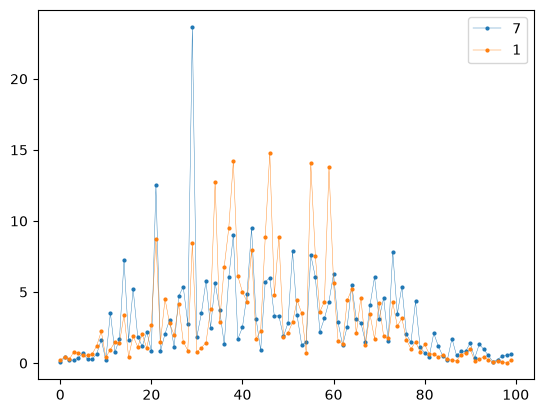

In [7]:
#Can plot intensity distribution over the channel number:
mask7 = Y==7
mask1 = Y==1
I7 = np.abs(E_hist[:,:,mask7])**2
I1 = np.abs(E_hist[:,:,mask1])**2
I_cumm7 = np.sum(I7, axis=2) 
I_cumm1 = np.sum(I1, axis=2) 
#plt.plot(I[-1,:], linewidth=0.3, marker="o", markersize=2)

plt.plot(I_cumm7[-1,:], linewidth=0.3, marker="o", markersize=2, label="7")
plt.plot(I_cumm1[-1,:], linewidth=0.3, marker="o", markersize=2, label="1")
plt.legend()

# Linear regression
with vs. without normalized energy

In [29]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = None #Sets number of samples you want to get in total
m = 10 #side length (pixel) of mnist image after downsampling
theta = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = False #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X_Train, Y_Train = get_data(values, "Training", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

theta, y_predict, accuracy = linear_regression(E_X_Train.T, Y_Train, E_X_Test.T, Y_Test)
print(accuracy)

[[1134    1]
 [  16 1012]]
0.9921405455386038


In [34]:
print(np.shape(E_X_Train))
mask7 = Y_Train==7
mask1 = Y_Train==1
print(np.sum(np.mean(E_X_Train[:,mask7])**2, axis=0))
print(np.sum(np.mean(E_X_Train[:,mask1])**2, axis=0))


(100, 13007)
(0.00995332460049286+0j)
(0.004382871894587103+0j)


In [26]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = None #Sets number of samples you want to get in total
m = 10 #side length (pixel) of mnist image after downsampling
theta = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = True #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X_Train, Y_Train = get_data(values, "Training", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

theta, y_predict, accuracy = linear_regression(E_X_Train.T, Y_Train, E_X_Test.T, Y_Test)
print(accuracy)

[[1133    2]
 [  14 1014]]
0.9926028663892742
